<a href="https://colab.research.google.com/github/tylerjohnbecker/Nonlinear_and_Data_Driven_Estimation/blob/main/BouncingBallNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
import math
import random
from scipy.integrate import odeint

In [2]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
extended_kalman_filter = import_local_or_github('extended_kalman_filter', directory='../Utility')
unscented_kalman_filter = import_local_or_github('unscented_kalman_filter', directory='../Utility')

Fetching from: 
<Response [200]>
Fetching from: 
<Response [200]>
Fetching from: 
<Response [200]>


In [3]:
try:
    import casadi as ca
except:
    !pip install casadi
    import casadi as ca

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 4.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


  Cloning https://github.com/vanbreugel-lab/pybounds to /tmp/pip-req-build-ixt2qptc
  Running command git clone --filter=blob:none --quiet https://github.com/vanbreugel-lab/pybounds /tmp/pip-req-build-ixt2qptc
  Resolved https://github.com/vanbreugel-lab/pybounds to commit b847eb839f75308ed8ba402f0e3356f6148d465e
  Preparing metadata (setup.py) ... done
  Created wheel for pybounds: filename=pybounds-0.0.13-py3-none-any.whl size=19568 sha256=23ecc651cff1bb59238f963338bb4a05318028a16f9a2fa45f06aa9a0a621f37
  Stored in directory: /tmp/pip-ephem-wheel-cache-8bfemju8/wheels/cb/f8/fb/ff1887f9a2f35c3edad7b1acb7da69437c1fd8d885a800578d
Successfully built pybounds


#Linear Dynamics

In [44]:
g = -9.8
x0 = np.array([0, 0, random.random() * 8 + 2, 0, 0, random.random() - .5])
m = random.random() * 5
r = random.random() * 2
e = random.random()
mu = random.random()
Im = 0.4 * m * r ** 2

In [47]:
def estimate_damping_from_cor(e, m, stiffness):

    # Calculate damping ratio from coefficient of restitution
    ln_e = np.log(e)

    xi = np.sqrt(ln_e**2 / (np.pi**2 + ln_e**2))

    # For very low e, increase damping further
    correction = 1.0 + (0.3 - e) * 2.0

    xi = ca.if_else(e < .3, xi, xi * correction);

    # Calculate critical damping
    damping = 2 * xi * np.sqrt(m * stiffness)

    damping = ca.if_else(ca.fabs(e - 1.0) < 1e-6, 0.0, damping);

    return np.array([damping]).flatten()[0]

In [76]:
def f_in_air_linear(x_vec, u_vec, g, r, Im, m):

    # Extract state variables
    x = x_vec[0]
    x_dot = x_vec[1]
    z = x_vec[2]
    z_dot = x_vec[3]
    theta = x_vec[4]
    theta_dot = x_vec[5]

    # Extract control inputs
    f_x = u_vec[0]
    f_z = u_vec[1]
    tor = u_vec[2]

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([ x_dot,
                                 0,
                                 z_dot,
                                 g,
                                 theta_dot,
                                 0])

    # f1 component: multiplied by control u1
    f_other_contribution = np.array([0,
                                     f_x / m,
                                     0,
                                     f_z / m,
                                     0,
                                     tor / Im])

    x_dot_vec = f0_contribution + f_other_contribution

    return x_dot_vec

In [77]:
def f_impact_linear(x_vec, u_vec, g, r, Im, m, e, mu, stiffness, damping):
    x_dot = x_vec[1]
    z_dot = x_vec[3]
    theta_dot = x_vec[5]
    z = x_vec[2]

    f_x, f_z, tau = u_vec[0], u_vec[1], u_vec[2]

    # Penetration depth (positive when in contact)
    penetration = r - z

    # Normal force (Hunt-Crossley contact model)
    # Only active when penetration > 0
    f_normal = stiffness * penetration - damping * penetration * z_dot
    f_normal = np.array([ca.if_else(f_normal > 0, f_normal, 0)]).flatten()[0]
    f_normal = np.array([ca.if_else(penetration > 0, f_normal, 0)]).flatten()[0]

    # Tangential velocity at contact point (bottom of ball)
    v_contact = x_dot - r * theta_dot

    # Friction force opposes contact point motion
    # If v_contact > 0 (sliding right), friction acts left (negative)
    # If v_contact < 0 (sliding left), friction acts right (positive)
    v_threshold = 0.1  # m/s - smoothing parameter
    friction_direction = np.tanh(v_contact / v_threshold)
    f_friction_ideal = -mu * f_normal * friction_direction

    # Cap friction force to prevent unrealistic accelerations
    max_friction_force = 1.0  # Newtons - tune based on your ball mass

    friction_sign = np.sign(f_friction_ideal)
    f_friction_ideal = friction_sign * f_friction_ideal

    f_friction = np.array([ca.if_else(f_friction_ideal > max_friction_force, max_friction_force, f_friction_ideal)]).flatten()[0] * friction_sign

    # f_friction = np.array([ca.if_else(f_friction_ideal > max_friction_force or f_friction_ideal < -max_friction_force, np.sign(f_friction_ideal) * max_friction_force, f_friction_ideal)]).flatten()[0]
    # f_friction = np.clip(f_friction_ideal, -max_friction_force, max_friction_force)

    # if v_contact > .5:
    #     print(f"v_contact: {v_contact} | rot: {r * theta_dot}")
    #     print(f"z: {z} | N: {f_normal } | fric: {f_friction} | dir: {friction_direction}")

    # Equations of motion
    x_dot_vec = np.array([
        x_dot,
        (f_x + f_friction) / m,
        z_dot,
        -g + (f_z + f_normal) / m,
        theta_dot,
        (tau - r * f_friction) / Im
    ])

    return x_dot_vec

In [51]:
def sigm_transition( z, r, width=.05):
    center = r + width
    return 1 / (1 + np.exp(-(z - center) / width))

In [81]:
def f_combined_linear(x_vec, u_vec, g=g, Im=Im, r=r, m=m, e=e, mu=mu, stiffness=100, transition_width=0.01):
    """
    Combined dynamics with smooth transition.
    """
    alpha = sigm_transition(x_vec[2], r, transition_width)

    f_air = f_in_air_linear(x_vec, u_vec, g, r, Im, m)
    f_cont = f_impact_linear(x_vec, u_vec, g, r, Im, m, e, mu, stiffness, estimate_damping_from_cor(e, m, stiffness))

    return alpha * f_air + (1 - alpha) * f_cont

In [63]:
def f_ode(x_vec, tsim, u_func, f):
    u_vec = u_func(x_vec, tsim)
    x_dot_vec = f(x_vec, u_vec)

    return x_dot_vec

# Basic Controllers

In [93]:
def u_go_right_slow(x_vec, tsim, target=1):

    right_diff = target - x_vec[1]

    return np.array([right_diff, 0, 0])

In [95]:
def u_go_right_fast(x_vec, tsim):
    return u_go_right_slow(x_vec, tsim, 10)

In [96]:
def u_go_left_slow(x_vec, tsim):
    return u_go_right_slow(x_vec, tsim, -1)

In [97]:
def u_go_left_fast(x_vec, tsim):
    return u_go_right_slow(x_vec, tsim, -10)

In [17]:
def u_bounce_slow(x_vec, tsim):
    return np.array([0, 7, 0])

In [18]:
def u_big_bounce(x_vec, tsim):
    return np.array([0, -10, 0])

In [19]:
def u_spin_right(x_vec, tsim):
    return np.array([0, 0, 1])

In [20]:
def u_spin_left(x_vec, tsim):
    return np.array([0, 0, -1])

In [22]:
def u_null(x_vec, tsim):
    return np.array([0, 0, 0])

## putting everything in a vector for randomly picking a controller

In [23]:
x_dot_controllers = [ u_go_right_slow, u_go_right_fast, u_go_left_slow, u_go_left_fast, u_null]
z_dot_controllers = [ u_bounce_slow, u_big_bounce, u_null ]
theta_dot_controllers = [ u_spin_right, u_spin_left, u_null ]

In [25]:
def get_random_controller():
    return lambda x_vec, tsim: random.choice(x_dot_controllers)(x_vec, tsim) + random.choice(z_dot_controllers)(x_vec, tsim) + random.choice(theta_dot_controllers)(x_vec, tsim)

# Generate Random Trajectories

In [40]:
# constants
g = -9.8
delta_t = .05

tsim = np.arange(0, 10, delta_t)

In [121]:
x0 = np.array([0, 0, random.random() * 8 + 2, 0, 0, random.random() - .5])
random.choice(x_dot_controllers)(x0, 0)

u_go_left_fast(x0, 0)

array([-10.,   0.,   0.])

In [125]:
def create_random_trajectory():

    # random variables
    x0 = np.array([0, 0, random.random() * 8 + 2, 0, 0, random.random() - .5])
    m = random.random() * 5
    r = random.random() * 2
    e = random.random()
    mu = random.random()
    Im = 0.4 * m * r ** 2

    # random controller selection
    u_rand_x = random.choice(x_dot_controllers)
    u_rand_z = random.choice(z_dot_controllers)
    u_rand_theta = random.choice(theta_dot_controllers)

    u_rand = lambda x_vec, tsim: u_rand_x(x_vec, tsim) + u_rand_z(x_vec, tsim) + u_rand_theta(x_vec, tsim)

    return np.array(odeint(f_ode, x0, tsim, args=(u_rand, f_combined_linear)))

Text(0, 0.5, 'theta_dot')

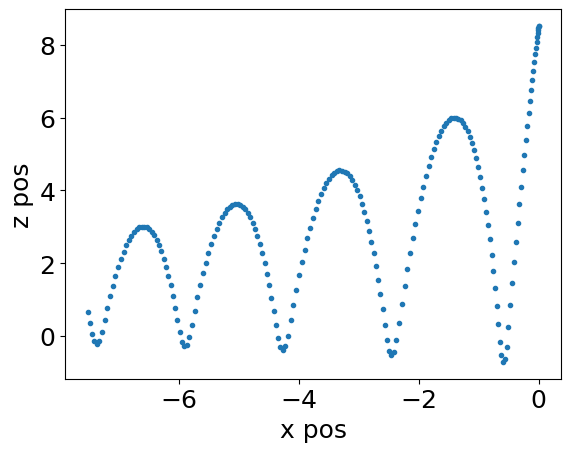

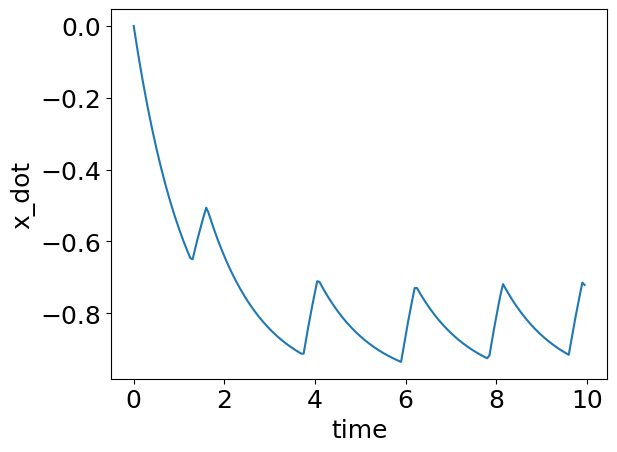

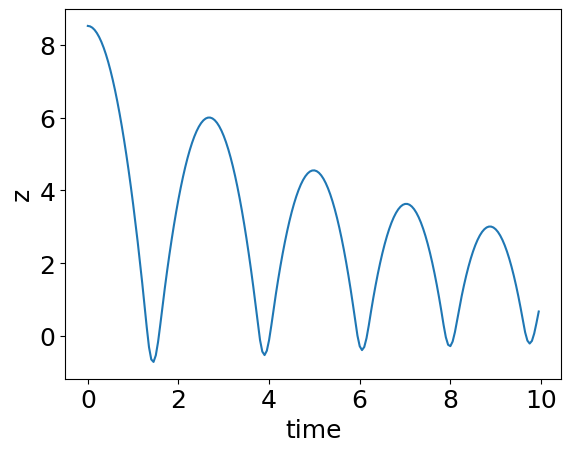

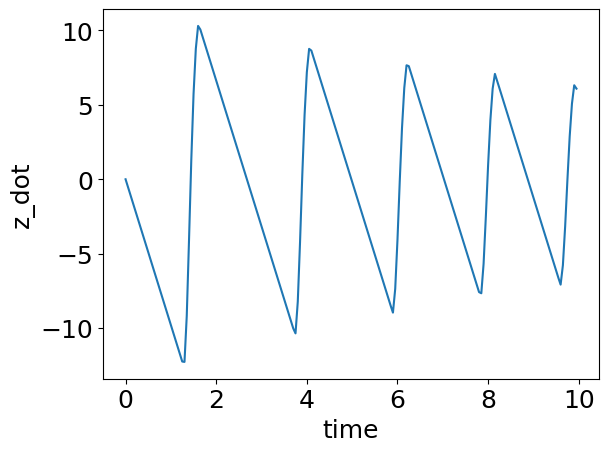

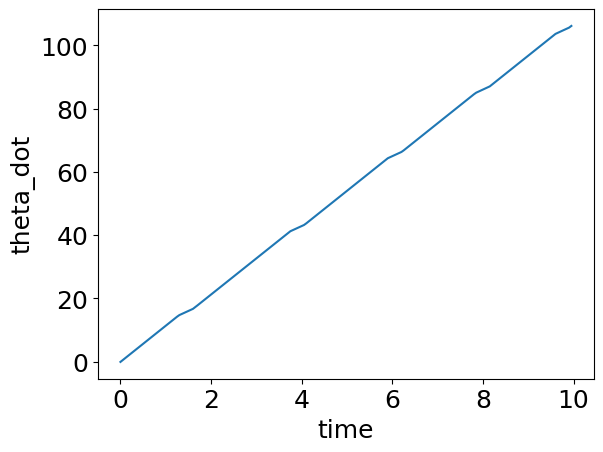

In [124]:
sol = create_random_trajectory()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(sol[:, 0], sol[:, 2], '.')
ax.set_xlabel('x pos')
ax.set_ylabel('z pos')

fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
ax3.plot(tsim, sol[:,1])
ax3.set_xlabel('time')
ax3.set_ylabel('x_dot')
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.plot(tsim, sol[:,2])
ax2.set_xlabel('time')
ax2.set_ylabel('z')
fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
ax3.plot(tsim, sol[:,3])
ax3.set_xlabel('time')
ax3.set_ylabel('z_dot')
fig3 = plt.figure()
ax3 = fig3.add_subplot(111)
ax3.plot(tsim, sol[:,5])
ax3.set_xlabel('time')
ax3.set_ylabel('theta_dot')